In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import joblib
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All imports successful")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\onahe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\onahe\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\wordnet.zip.
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\onahe\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\omw-1.4.zip.


All imports successful


In [5]:
# Load the CFPB dataset
df = pd.read_csv('../data/complaints_processed.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (162421, 3)

Columns: ['Unnamed: 0', 'product', 'narrative']

First 3 rows:


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...


In [6]:
# Check class distribution
print("Product class distribution:")
print(df['product'].value_counts())
print("\nMissing values:")
print(df.isnull().sum())

# Drop rows where narrative or product is missing
df = df.dropna(subset=['narrative', 'product'])
print(f"\nRows after dropping nulls: {len(df)}")

Product class distribution:
product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64

Missing values:
Unnamed: 0     0
product        0
narrative     10
dtype: int64

Rows after dropping nulls: 162411


C:\Users\onahe\AppData\Local\Temp\ipykernel_4796\3142689095.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='product', data=df, order=order, palette='Blues_r')


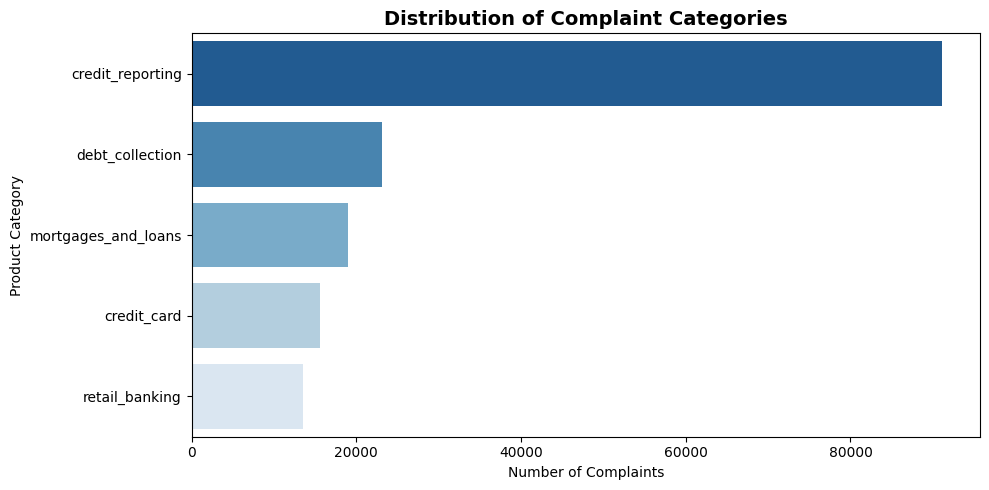

product
credit_reporting       91172
debt_collection        23148
mortgages_and_loans    18990
credit_card            15566
retail_banking         13535
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(10, 5))
order = df['product'].value_counts().index
sns.countplot(y='product', data=df, order=order, palette='Blues_r')
plt.title('Distribution of Complaint Categories', fontsize=14, fontweight='bold')
plt.xlabel('Number of Complaints')
plt.ylabel('Product Category')
plt.tight_layout()
plt.savefig('../models/eda_category_distribution.png', dpi=150)
plt.show()
print(df['product'].value_counts())

Text Length Statistics:
count    162411.000000
mean         80.232798
std         108.872213
min           1.000000
25%          27.000000
50%          50.000000
75%          95.000000
max        2685.000000
Name: text_length, dtype: float64


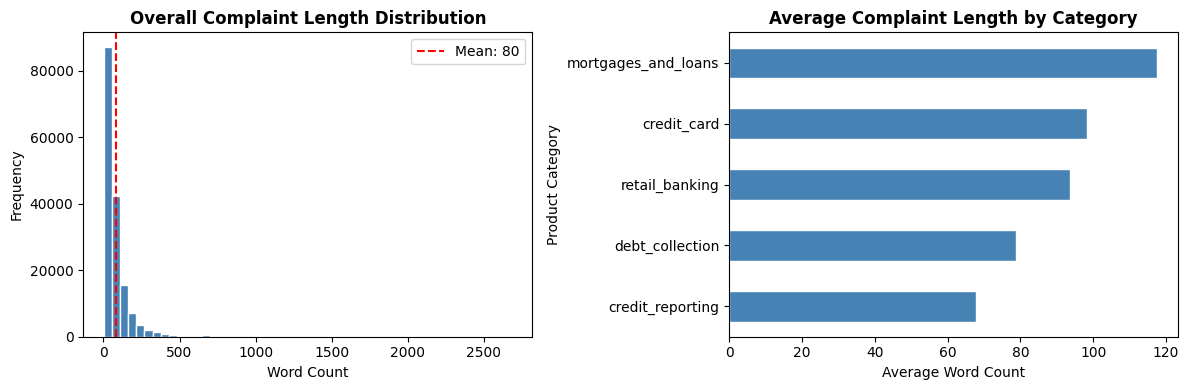

In [8]:
df['text_length'] = df['narrative'].apply(lambda x: len(x.split()))

print("Text Length Statistics:")
print(df['text_length'].describe())

plt.figure(figsize=(12, 4))

# Overall distribution
plt.subplot(1, 2, 1)
plt.hist(df['text_length'], bins=50, color='steelblue', edgecolor='white')
plt.title('Overall Complaint Length Distribution', fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.axvline(df['text_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['text_length'].mean():.0f}")
plt.legend()

# By category
plt.subplot(1, 2, 2)
df.groupby('product')['text_length'].mean().sort_values().plot(
    kind='barh', color='steelblue', edgecolor='white'
)
plt.title('Average Complaint Length by Category', fontweight='bold')
plt.xlabel('Average Word Count')
plt.ylabel('Product Category')

plt.tight_layout()
plt.savefig('../models/eda_text_length.png', dpi=150)
plt.show()

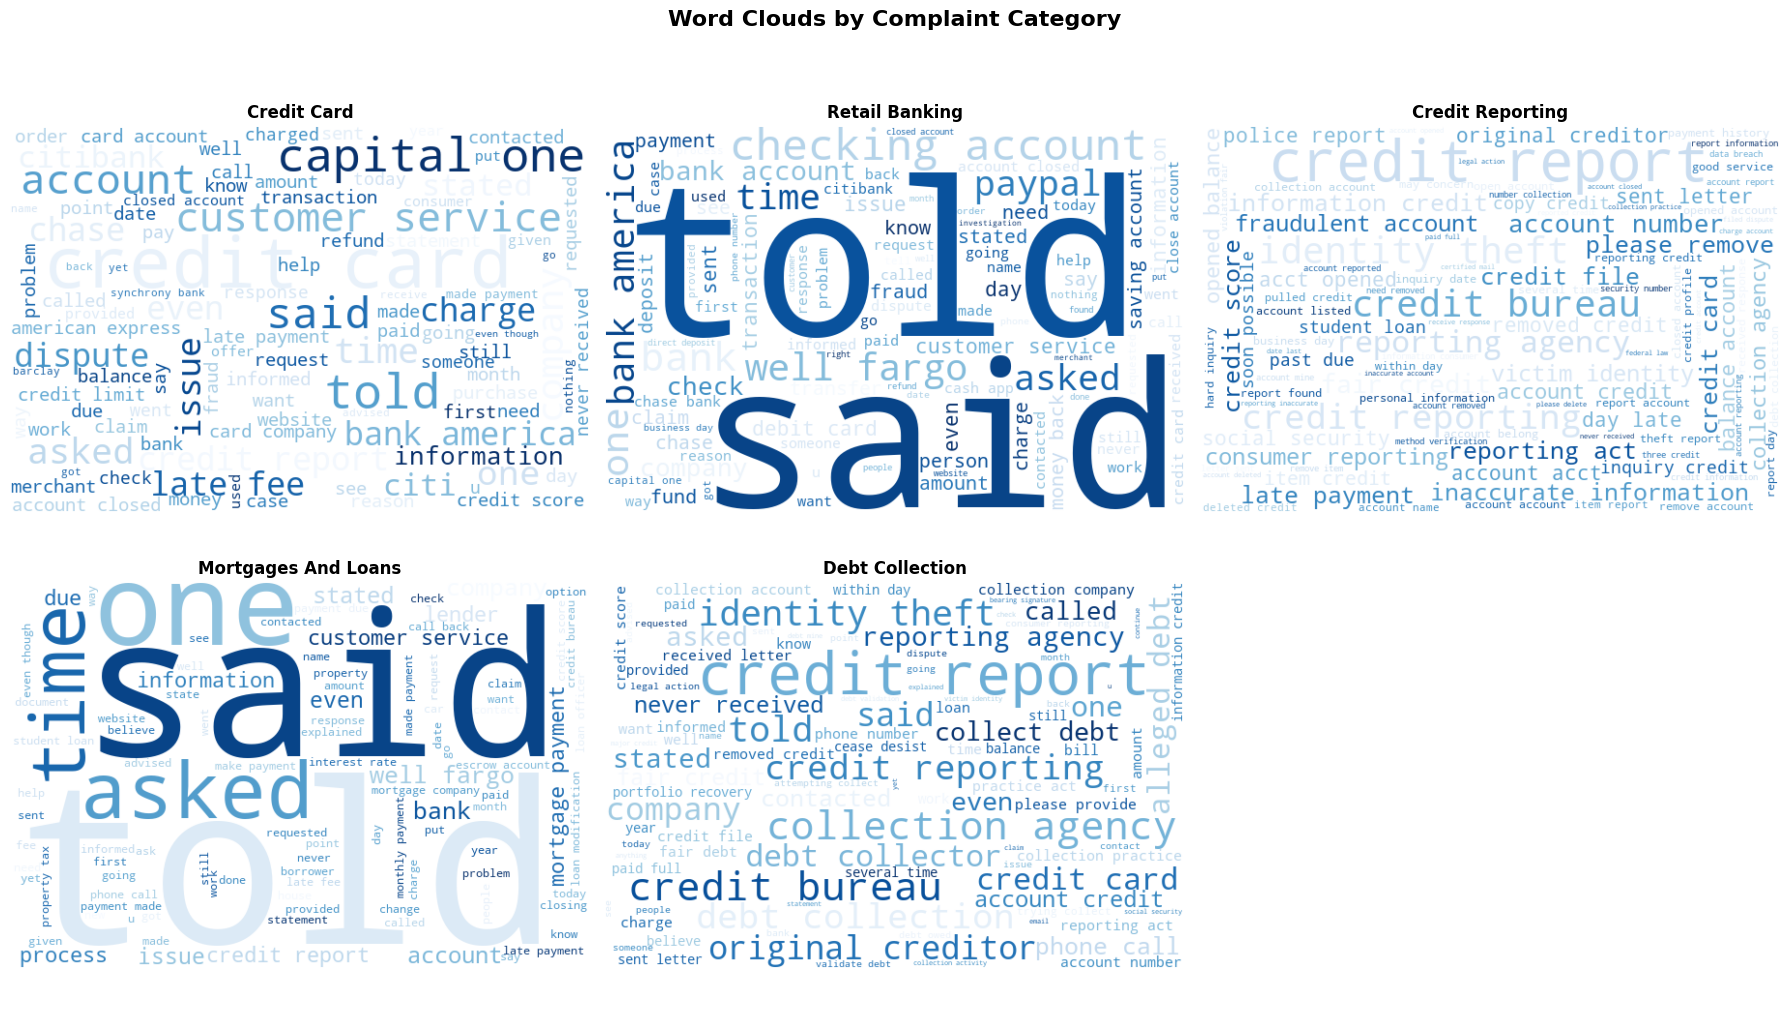

In [9]:
from wordcloud import WordCloud

# Install wordcloud if not already: pip install wordcloud
categories = df['product'].unique()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, category in enumerate(categories):
    text = ' '.join(df[df['product'] == category]['narrative'].dropna().values)
    wordcloud = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='Blues',
        max_words=100
    ).generate(text)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(category.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].axis('off')

# Hide the 6th subplot if only 5 categories
if len(categories) < 6:
    axes[-1].axis('off')

plt.suptitle('Word Clouds by Complaint Category', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../models/eda_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

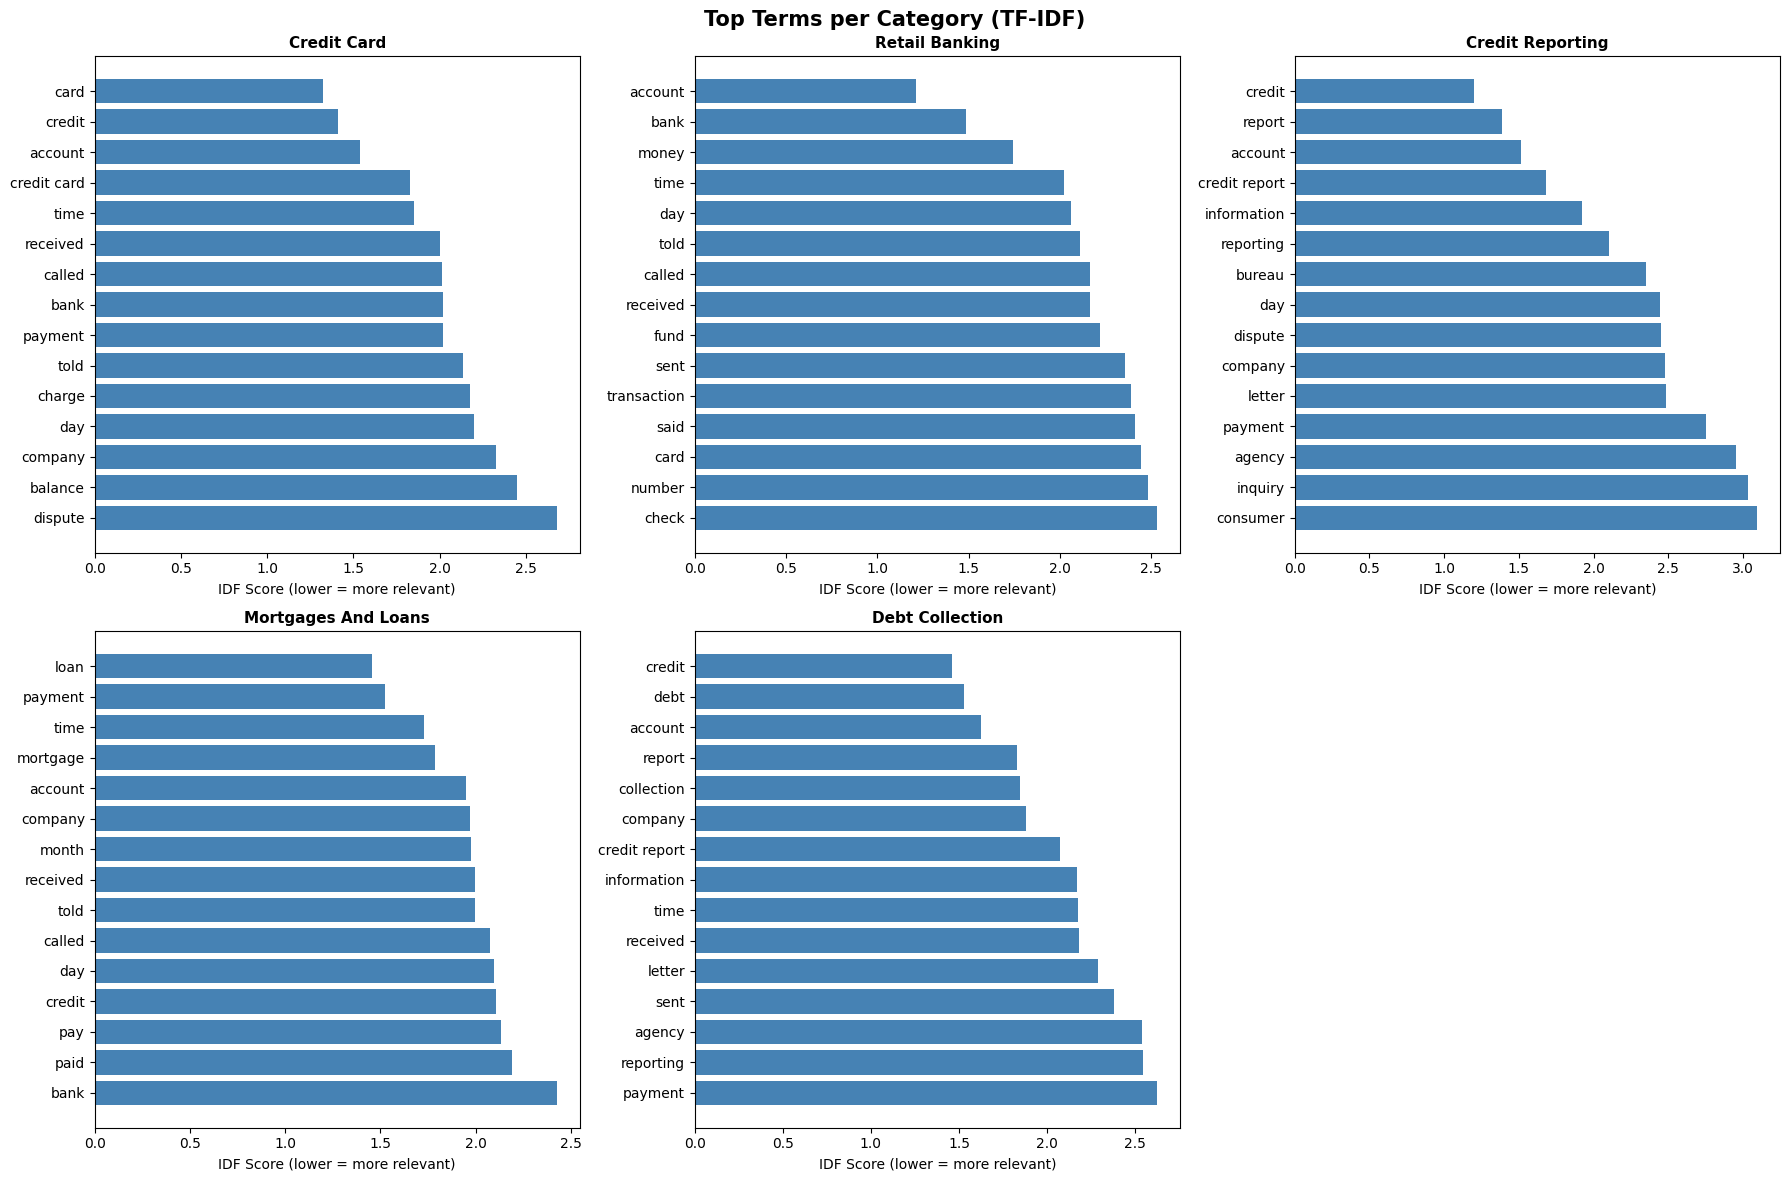

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer as TfidfViz

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, category in enumerate(df['product'].unique()):
    subset = df[df['product'] == category]['narrative'].dropna()
    
    tfidf_temp = TfidfViz(max_features=15, stop_words='english', ngram_range=(1,2))
    tfidf_temp.fit_transform(subset)
    
    terms = tfidf_temp.get_feature_names_out()
    scores = tfidf_temp.idf_
    
    # Lower IDF = more important in this category
    term_scores = pd.Series(scores, index=terms).sort_values()
    
    axes[i].barh(term_scores.index, term_scores.values, color='steelblue')
    axes[i].set_title(category.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('IDF Score (lower = more relevant)')
    axes[i].invert_yaxis()

if len(df['product'].unique()) < 6:
    axes[-1].axis('off')

plt.suptitle('Top Terms per Category (TF-IDF)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/eda_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

print("Preprocessing text... this may take a few minutes on 160k rows")
df['clean_text'] = df['narrative'].apply(preprocess)
print("Done.")
df[['narrative', 'clean_text']].head(3)

Preprocessing text... this may take a few minutes on 160k rows
Done.


,narrative,clean_text
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...


In [12]:
X = df['clean_text']
y = df['product']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Vectorization complete.")
print(f"Feature matrix shape: {X_train_tfidf.shape}")

Training samples: 129928
Testing samples:  32483
Vectorization complete.
Feature matrix shape: (129928, 50000)


In [13]:
print("Training LinearSVC model...")

model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
model.fit(X_train_tfidf, y_train)

print("Training complete.")

Training LinearSVC model...
Training complete.


Accuracy: 89.14 %

Classification Report:
                     precision    recall  f1-score   support

        credit_card       0.81      0.79      0.80      3113
   credit_reporting       0.92      0.95      0.94     18235
    debt_collection       0.84      0.78      0.81      4630
mortgages_and_loans       0.87      0.83      0.85      3798
     retail_banking       0.87      0.88      0.87      2707

           accuracy                           0.89     32483
          macro avg       0.86      0.85      0.85     32483
       weighted avg       0.89      0.89      0.89     32483



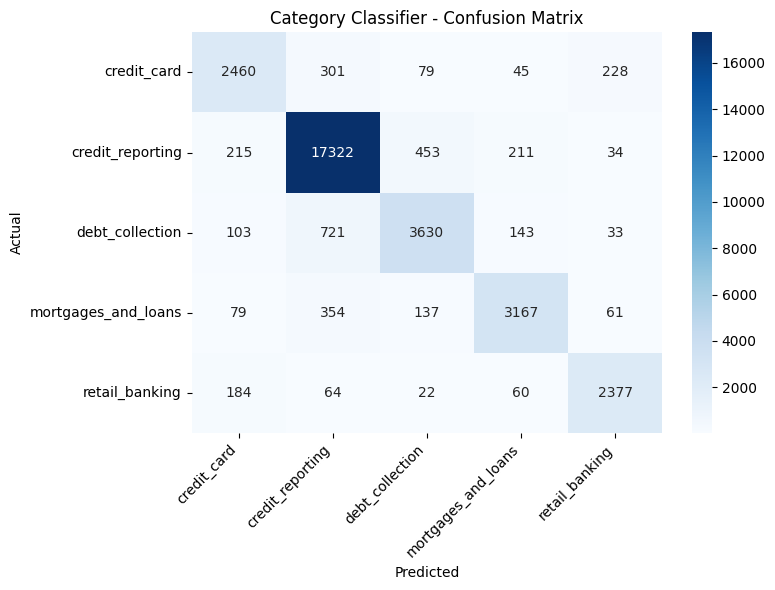

In [14]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_,
            yticklabels=model.classes_, cmap='Blues')
plt.title('Category Classifier - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save model and vectorizer
joblib.dump(model, '../models/category_model.pkl')
joblib.dump(vectorizer, '../models/category_vectorizer.pkl')

print("category_model.pkl saved successfully")
print("category_vectorizer.pkl saved successfully")

category_model.pkl saved successfully
category_vectorizer.pkl saved successfully
